# Análise - Vitórias das Escuderias na Formula 1


##  1. Introdução

A Fórmula 1, principal categoria do automobilismo mundial, possui um histórico extenso de corridas e construtores. Com base em dados históricos desde 1950, esta análise visa identificar as escuderias com maior número de vitórias, bem como compreender como essas vitórias se distribuíram ao longo das décadas.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Identificar as equipes (construtores) com o maior número de vitórias desde 1950;

    - Analisar a distribuição dessas vitórias por década: 1950s, 1960s, ..., até 2020s.


## 3. Metodologia
Inicialmente, foram utilizadas três bases de dados principais:

    - results.csv: Contém os resultados das corridas (inclusive posição de chegada);
    - constructors.csv: Dados sobre as equipes (construtores);
    - races.csv: Informações sobre cada corrida, incluindo o ano.

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [2]:
import pandas as pd

# Carregandos as bases
resultados = pd.read_csv("./bases/results.csv", delimiter=",")
construtores = pd.read_csv("./bases/constructors.csv", delimiter=",")
corridas = pd.read_csv("./bases/races.csv", delimiter=",")

# Filtrando apenas os vencedores (posição 1 em cada corrida)
vencedores = resultados[resultados['positionOrder'] == 1]

# Juntando os dados com informações dos construtores
vencedores = vencedores.merge(construtores, on="constructorId", how="left")

# Adicionando o ano da corrida
vencedores = vencedores.merge(corridas[["raceId", "year"]], on="raceId", how="left")

# Criando uma nova coluna para representar a década
vencedores["decade"] = (vencedores["year"] // 10) * 10

## 4. Análise de Dados

#### 4.1 Total de Vitórias por Construtor

A contagem total de vitórias por equipe (construtor) foi realizada com base nas corridas em que o construtor terminou na primeira posição (positionOrder == 1):

In [3]:
total_vitorias = vencedores["name"].value_counts().reset_index()
total_vitorias.columns = ["constructor", "total_wins"]
print(total_vitorias)

        constructor  total_wins
0           Ferrari         249
1           McLaren         185
2          Mercedes         129
3          Red Bull         122
4          Williams         114
5        Team Lotus          45
6           Renault          35
7          Benetton          27
8           Brabham          23
9           Tyrrell          23
10     Lotus-Climax          22
11              BRM          17
12    Cooper-Climax          12
13       Alfa Romeo          11
14       Lotus-Ford          11
15          Vanwall          10
16       Matra-Ford           9
17           Ligier           9
18         Maserati           9
19    Brabham-Repco           8
20            Brawn           8
21     Kurtis Kraft           5
22           Jordan           4
23     McLaren-Ford           4
24           Watson           3
25            March           3
26            Honda           3
27             Wolf           3
28   Brabham-Climax           2
29         Lotus F1           2
30      

Essa tabela fornece um ranking dos construtores mais vitoriosos da história da Fórmula 1 desde 1950, permitindo identificar o domínio histórico de determinadas equipes.

#### 4.2 Vitórias por Década

Para compreender como o sucesso das equipes evoluiu ao longo do tempo, a análise foi segmentada por décadas:

In [4]:
vitorias_por_decada = vencedores.groupby(["decade", "name"]).size().reset_index(name="wins")
print(vitorias_por_decada)

    decade           name  wins
0     1950     Alfa Romeo    11
1     1950            BRM     1
2     1950         Cooper     2
3     1950  Cooper-Climax     5
4     1950        Epperly     2
..     ...            ...   ...
77    2020        Ferrari    10
78    2020        McLaren     7
79    2020       Mercedes    27
80    2020   Racing Point     1
81    2020       Red Bull    60

[82 rows x 3 columns]


Essa segmentação por década nos permite observar, por exemplo, se o domínio de uma equipe foi concentrado em um período específico ou distribuído ao longo do tempo. Também facilita a identificação de mudanças de hegemonia entre décadas.

## 5. Conclusão

A análise realizada permite obter uma visão clara da evolução histórica da competitividade entre as equipes na Fórmula 1. Dentre os principais aprendizados:

    - Algumas equipes acumulam vitórias de forma consistente ao longo de várias décadas, demonstrando estabilidade e           investimento contínuo em desempenho;

    - Outras equipes possuem picos de desempenho concentrados em uma única década, refletindo períodos específicos de inovação técnica ou vantagem competitiva;

    - A análise por década também revela transições de domínio, como a ascensão de novas equipes e o declínio de outras.

C:\Users\bruno\AppData\Local\Temp\ipykernel_5544\806119990.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dados, x="name", y="wins", palette=cores)
C:\Users\bruno\AppData\Local\Temp\ipykernel_5544\806119990.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dados, x="name", y="wins", palette=cores)
C:\Users\bruno\AppData\Local\Temp\ipykernel_5544\806119990.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dados, x="name", y="wins", palette=cores)


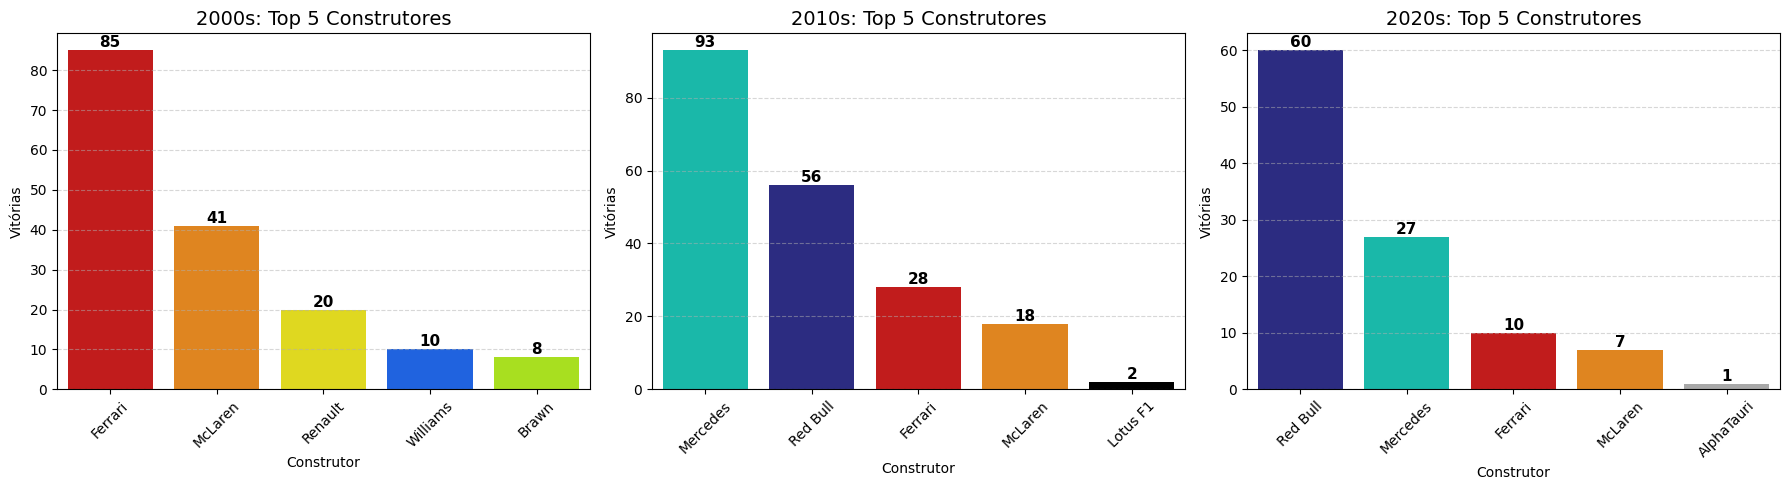

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionário com cores personalizadas por escuderia
cores_personalizadas = {
    "Ferrari": "#DC0000",       # Vermelho Ferrari
    "McLaren": "#FF8700",       # Laranja McLaren
    "Renault": "#FFF500",       # Amarelo
    "Williams": "#005AFF",      # Azul
    "Brawn": "#B6FF00",         # Verde Claro
    "Red Bull": "#1E1E8F",      # Azul Escuro
    "Mercedes": "#00D2BE",      # Ciano
    "Lotus F1": "#000000",         # Preto
    "AlphaTauri": "#A8A8A8",   # Cinza
}

# Filtrar décadas e obter os 5 mais vitoriosos por década
decadas = [2000, 2010, 2020]
top5_por_decada = {}

# Guardar todas as equipes envolvidas
construtores_utilizados = set()

for decada in decadas:
    top5 = (
        vitorias_por_decada[vitorias_por_decada["decade"] == decada]
        .sort_values(by="wins", ascending=False)
        .head(5)
    )
    top5_por_decada[decada] = top5
    construtores_utilizados.update(top5["name"].tolist())

# Verifica se há escuderias não listadas manualmente
escuderias_faltando = construtores_utilizados - set(cores_personalizadas.keys())
if escuderias_faltando:
    print("⚠️ Escuderias sem cor definida:", escuderias_faltando)

# Plotando os gráficos
plt.figure(figsize=(18, 5))

for i, decada in enumerate(decadas, 1):
    dados = top5_por_decada[decada]

    # Obter lista de cores na ordem dos construtores
    cores = [cores_personalizadas.get(nome, "#888888") for nome in dados["name"]]

    # Subplot
    plt.subplot(1, 3, i)
    ax = sns.barplot(data=dados, x="name", y="wins", palette=cores)

    plt.title(f"{decada}s: Top 5 Construtores", fontsize=14)
    plt.xlabel("Construtor")
    plt.ylabel("Vitórias")
    plt.xticks(rotation=45)

    # Adicionar valores nas colunas
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

    plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


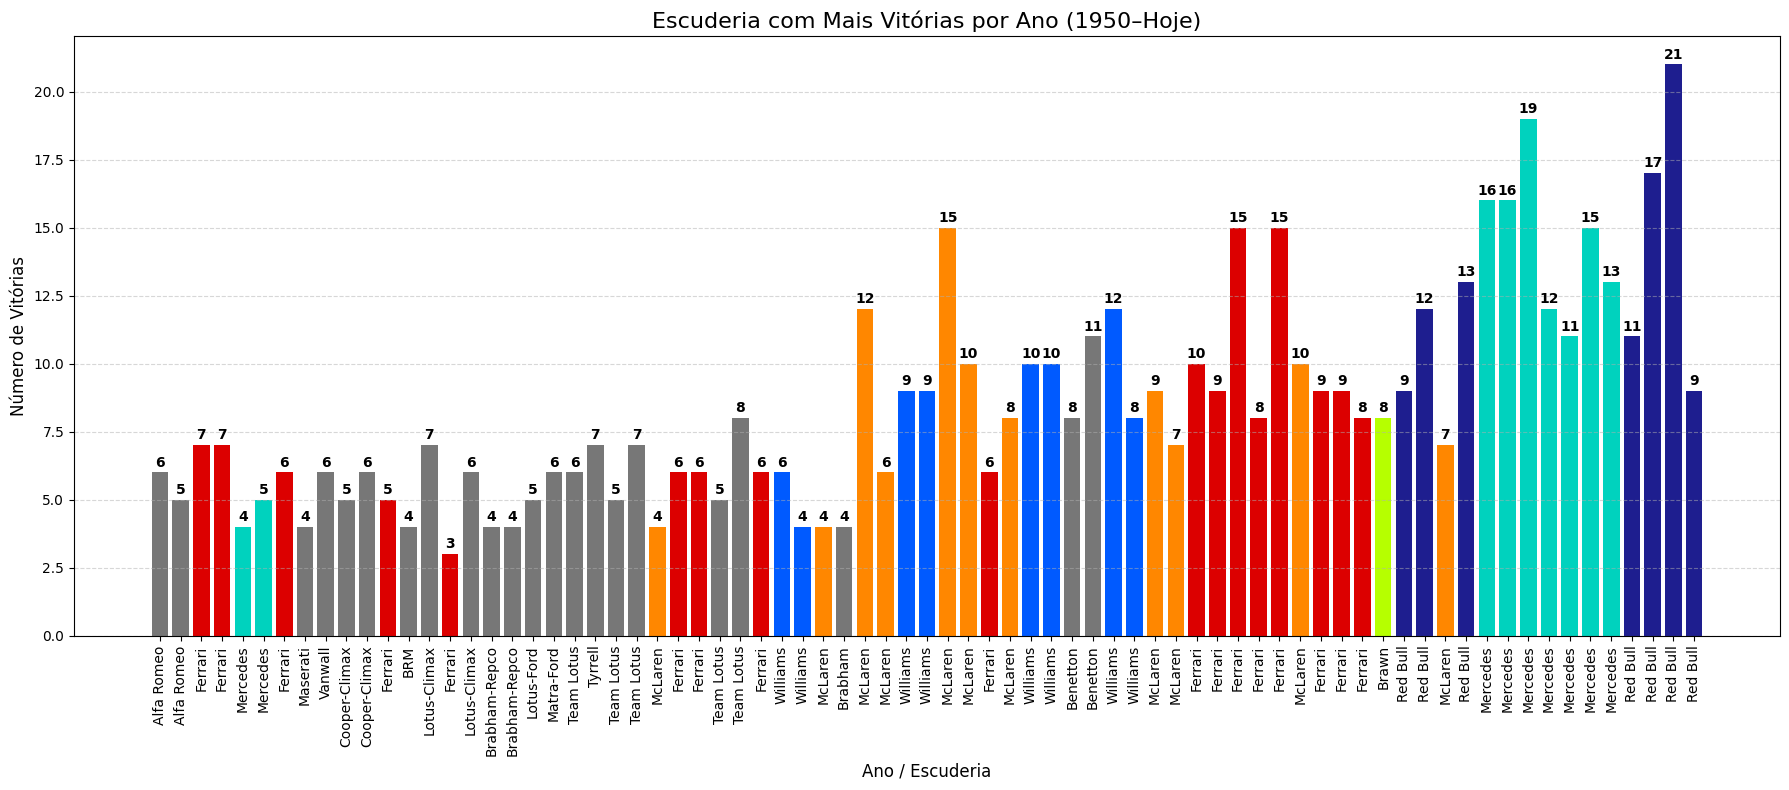

In [6]:
import matplotlib.pyplot as plt

# Agrupar por ano e escuderia, contar vitórias (já feito)
vitorias_ano = vencedores.groupby(["year", "name"]).size().reset_index(name="wins")

# Para cada ano, pegar a escuderia com mais vitórias
max_vitorias_por_ano = vitorias_ano.loc[vitorias_ano.groupby("year")["wins"].idxmax()]

# Ordenar pelo ano (por segurança)
max_vitorias_por_ano = max_vitorias_por_ano.sort_values("year")

# Preparar o gráfico
fig, ax = plt.subplots(figsize=(18, 8))

# Barras: uma barra por ano, altura = número de vitórias da escuderia que mais venceu
bars = ax.bar(
    max_vitorias_por_ano["year"],
    max_vitorias_por_ano["wins"],
    color=[cores_personalizadas.get(esc, "#777777") for esc in max_vitorias_por_ano["name"]]
)

# Colocar o nome da escuderia como label abaixo do eixo x, usando ticks personalizados
ax.set_xticks(max_vitorias_por_ano["year"])
ax.set_xticklabels(max_vitorias_por_ano["name"], rotation=90)

# Colocar o número de vitórias acima da barra
for bar, vitoria in zip(bars, max_vitorias_por_ano["wins"]):
    altura = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.1,
        str(vitoria),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# Personalização do gráfico
plt.title("Escuderia com Mais Vitórias por Ano (1950–Hoje)", fontsize=16)
plt.xlabel("Ano / Escuderia", fontsize=12)
plt.ylabel("Número de Vitórias", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Análise - Ultrapassagem por corrida


##  1. Introdução

A Fórmula 1 é conhecida não apenas por sua velocidade, mas também pela complexidade estratégica das corridas. Um dos elementos mais emocionantes das provas são as ultrapassagens, ou seja, mudanças de posição durante a corrida que indicam disputas intensas entre os pilotos. 

Nesta análise, utilizamos dados oficiais de tempos de volta para estimar o número de ultrapassagens ocorridas em cada corrida entre os pilotos que terminaram a prova.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Estimar o número de ultrapassagens por corrida com base na variação de posição volta a volta;

    - Identificar quais corridas tiveram o maior número de ultrapassagens entre os pilotos que completaram a prova;

    - Observar possíveis padrões de corridas com alta movimentação de posições.


## 3. Metodologia
Inicialmente, foram utilizadas três bases de dados principais:

    - lap_times.csv: contém os tempos de volta de cada piloto por corrida;
    - results.csv: traz o resultado final de cada piloto, incluindo o status (completou ou não a corrida);
    - races.csv: opcional, para adicionar contexto com ano, circuito, etc.

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [8]:
import pandas as pd

# Carregando os dados
lap_times = pd.read_csv("./bases/lap_times.csv")
results = pd.read_csv("./bases/results.csv")
races = pd.read_csv("./bases/races.csv")  # <- NOVO

# Filtrando apenas pilotos que completaram a prova
finished_drivers = results[results["statusId"] == 1][["raceId", "driverId"]]

# Unindo dados de volta com dados de finalização
laps = lap_times.merge(finished_drivers, on=["raceId", "driverId"])

# Ordenando voltas por tempo e definindo posição por volta
laps = laps.sort_values(by=["raceId", "lap", "milliseconds"])
laps["position"] = laps.groupby(["raceId", "lap"])["milliseconds"].rank(method="min")

# Calculando mudança de posição em relação à volta anterior
laps["prev_position"] = laps.groupby(["raceId", "driverId"])["position"].shift(1)
laps["position_change"] = laps["prev_position"] - laps["position"]
laps["changed"] = laps["position_change"].fillna(0) != 0

# Contando total de mudanças por corrida
ultrapassagens = laps.groupby("raceId")["changed"].sum().reset_index(name="ultrapassagens")

# Adicionando nome e ano da corrida
ultrapassagens = ultrapassagens.merge(races[["raceId", "name", "year"]], on="raceId", how="left")
ultrapassagens["corrida"] = ultrapassagens["year"].astype(str) + " - " + ultrapassagens["name"]

# Ordenar para exibir top 10
top10 = ultrapassagens.sort_values(by="ultrapassagens", ascending=False).head(10)

# Exportar CSV com nome legível
ultrapassagens.to_csv("ultrapassagens_por_corrida.csv", index=False)

# Visualização rápida
print(top10[["corrida", "ultrapassagens"]])

                         corrida  ultrapassagens
452     2020 - Sakhir Grand Prix            1213
302     2013 - Monaco Grand Prix            1012
510      2023 - Dutch Grand Prix            1004
373  2016 - Brazilian Grand Prix             971
490      2022 - Dutch Grand Prix             926
525      2024 - Miami Grand Prix             914
484   2022 - Canadian Grand Prix             892
496  2022 - São Paulo Grand Prix             890
340     2015 - Monaco Grand Prix             872
430  2019 - Singapore Grand Prix             865


## 4. Conclusão
A análise revelou padrões importantes sobre a competitividade entre as escuderias na Fórmula 1:

    - Algumas equipes mantêm um desempenho dominante por décadas;

    - Outras apresentam picos de performance em períodos específicos;

    - A divisão por década permite identificar mudanças de hegemonia no esporte.

Além disso, exploramos as corridas com maior número de ultrapassagens, destacando os eventos mais movimentados da história recente. O gráfico abaixo mostra as 10 corridas com mais ultrapassagens registradas:

C:\Users\bruno\AppData\Local\Temp\ipykernel_5544\2448699558.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="corrida", y="ultrapassagens", data=top10, palette="rocket")


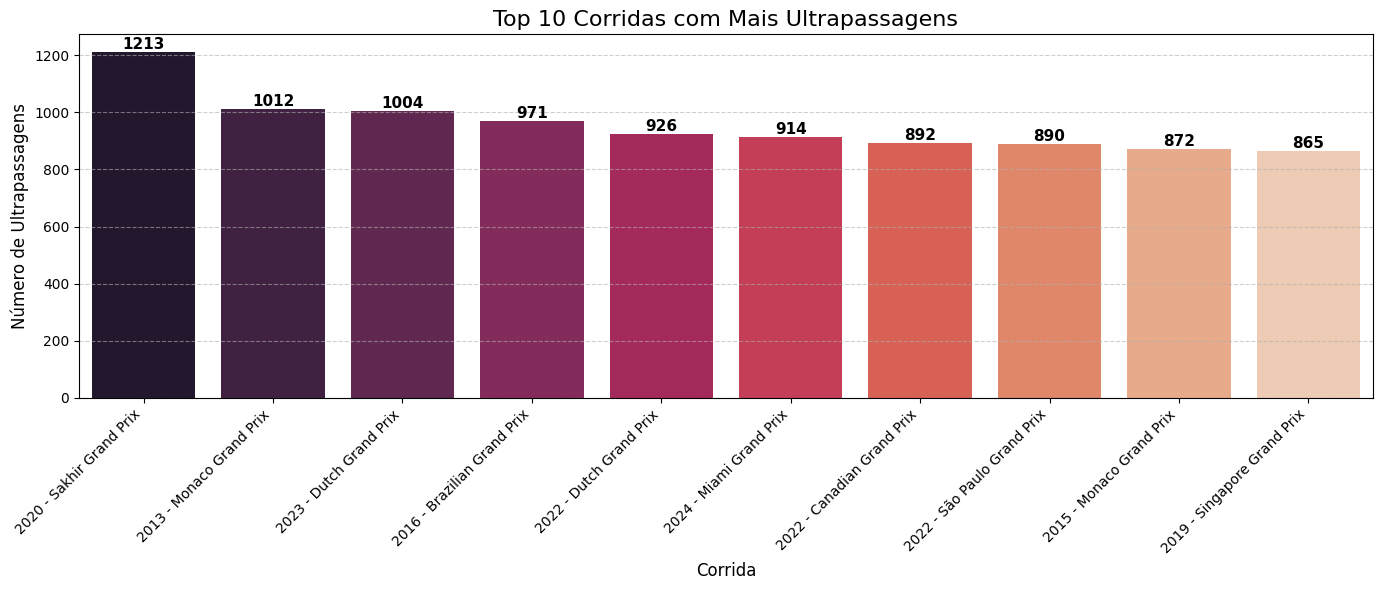

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
ultrapassagens = pd.read_csv("ultrapassagens_por_corrida.csv")
corridas = pd.read_csv("./bases/races.csv")

# Renomear colunas
ultrapassagens.columns = ["raceId", "ultrapassagens","nome","ano", "corrida"]

# Juntar com informações da corrida (nome do GP e ano)
ultrapassagens = ultrapassagens.merge(corridas[["raceId", "name", "year"]], on="raceId", how="left")

# Criar rótulo mais amigável: "Ano - Nome do GP"
ultrapassagens["corrida"] = ultrapassagens["year"].astype(str) + " - " + ultrapassagens["name"]

# Selecionar top 10
top10 = ultrapassagens.sort_values(by="ultrapassagens", ascending=False).head(10)

# Gráfico
plt.figure(figsize=(14, 6))
ax = sns.barplot(x="corrida", y="ultrapassagens", data=top10, palette="rocket")

# Customizações
plt.title("Top 10 Corridas com Mais Ultrapassagens", fontsize=16)
plt.xlabel("Corrida", fontsize=12)
plt.ylabel("Número de Ultrapassagens", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Labels nas barras
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()


# Analise - Evolução do tempo médio de pit stop ao longo dos anos

## 1. Introdução

A Fórmula 1, além de ser uma competição entre pilotos e equipes, também é uma corrida de engenharia e estratégia. Os pit stops, momentos cruciais em uma corrida, têm se tornado cada vez mais rápidos e eficientes com o avanço da tecnologia e treino das equipes. Esta análise explora como o tempo médio de pit stop evoluiu ao longo dos anos.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Analisar o tempo médio de pit stop por temporada, ao longo dos anos (desde 2011).

    - Identificar tendências: houve redução significativa nos tempos?

## 3. Metodologia

Inicialmente, foram utilizadas duas bases de dados principais:

    - pit_stops.csv: Contém os dados dos pit stops (inclusive o tempo de duração);
    - races.csv: Informações sobre cada corrida, incluindo o ano.

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [19]:
import pandas as pd

# Carregando as bases
pit_stops = pd.read_csv("./bases/pit_stops.csv", delimiter=",")
races = pd.read_csv("./bases/races.csv", delimiter=",")

# Juntando com o ano da corrida
pit_stops = pit_stops.merge(races[["raceId", "year"]], on="raceId", how="left")

# Garantir que duração está em segundos
pit_stops["duration"] = pd.to_numeric(pit_stops["duration"], errors="coerce")

## 4. Análise de Dados

#### 4.1 Tempo médio de pit stop por ano
A contagem do tempo médio de pit stop por ano foi realizada com base nos dados de cada corrida, e de cada construtor:

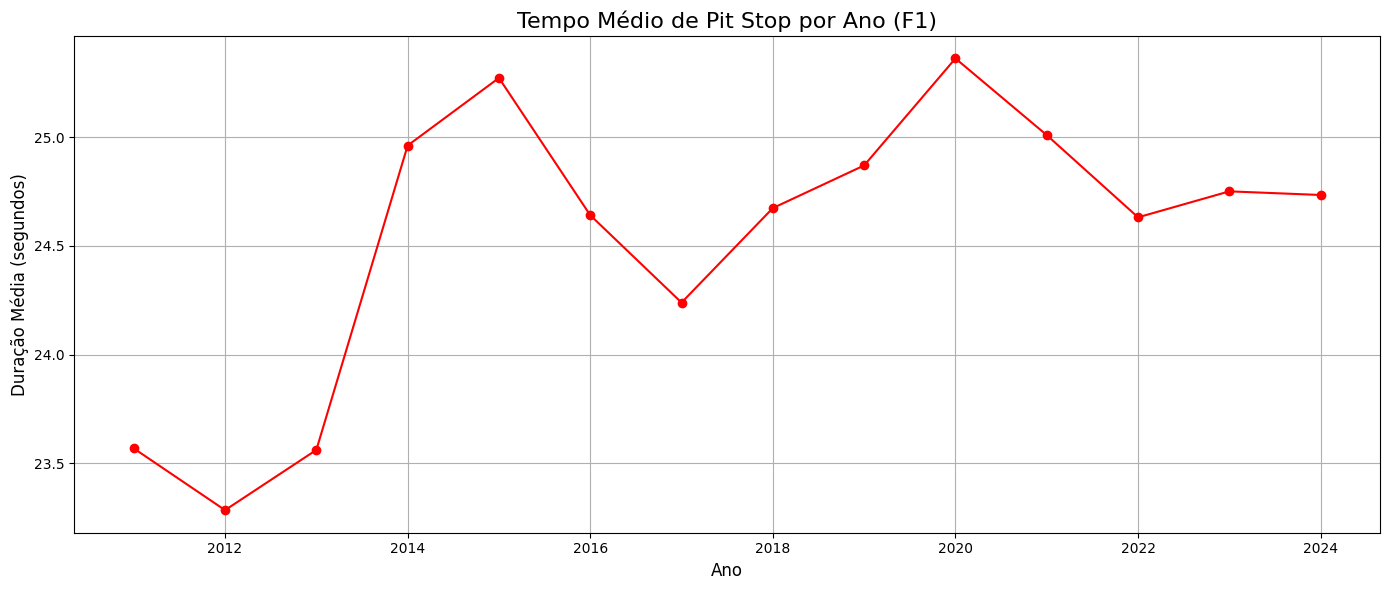

In [20]:
media_por_ano = pit_stops.groupby("year")["duration"].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(media_por_ano["year"], media_por_ano["duration"], marker='o', color='red')
plt.title("Tempo Médio de Pit Stop por Ano (F1)", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Duração Média (segundos)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.2 Quantidade de pit stops registrados por ano (para validar dados)

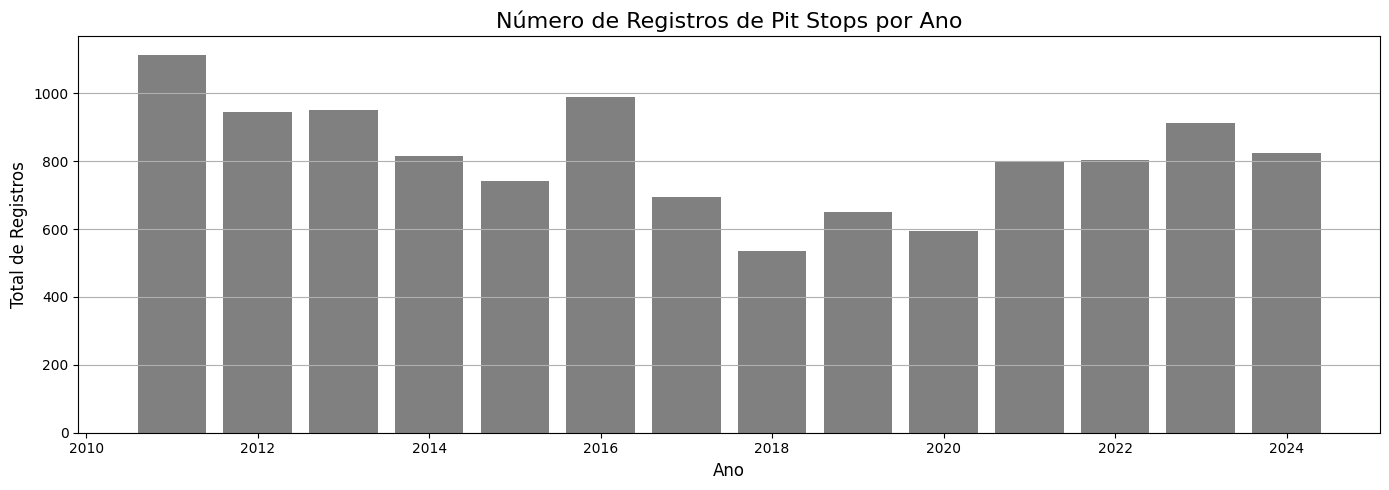

In [21]:
contagem = pit_stops.groupby("year").size().reset_index(name="qtd_pit_stops")

plt.figure(figsize=(14, 5))
plt.bar(contagem["year"], contagem["qtd_pit_stops"], color="gray")
plt.title("Número de Registros de Pit Stops por Ano", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Total de Registros", fontsize=12)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

## 5. Conclusão

    - O tempo médio de pit stop reduziu drasticamente a partir dos anos 2000, refletindo avanços técnicos e operacionais.

    - Houve anos em que os tempos aumentaram, indicando mudanças de regulamento, pneus ou restrições de segurança.

    - Equipes com mais recursos tendem a manter tempos menores de parada.

# Análise - Circuitos Favoráveis a Vitórias de Escuderias
## 1. Introdução
Na Fórmula 1, certos circuitos históricos parecem favorecer determinados construtores, seja por características técnicas da pista, experiência acumulada, ou adaptação de seus carros àquelas condições. Essa análise explora essas correlações entre escuderias e circuitos, visando identificar padrões de domínio ao longo do tempo.

## 2. Objetivo
Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

Identificar quais escuderias apresentam maior número de vitórias em cada circuito;

Verificar se determinados circuitos historicamente favorecem uma escuderia específica;

Calcular a média de vitórias das escuderias por circuito e explorar a variação de vencedores por pista.

## 3. Metodologia
Foram utilizadas as seguintes bases de dados:

`results.csv: Resultados individuais por piloto em cada corrida;`

`constructors.csv: Informações sobre as escuderias (construtores);`

`races.csv: Dados das corridas (incluindo o circuito e o ano);`

`circuits.csv: Detalhes sobre os circuitos.`

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados
As vitórias foram filtradas utilizando positionOrder == 1. As informações foram agrupadas por constructorName e circuitName para contagem de vitórias, e posteriormente, foi calculada a média de vitórias por circuito, incluindo zeros para circuitos nos quais a equipe nunca venceu.

In [24]:
import pandas as pd

# Carregando bases
races = pd.read_csv("./bases/races.csv")
constructors = pd.read_csv("./bases/constructors.csv")
results = pd.read_csv("./bases/results.csv")
circuits = pd.read_csv("./bases/circuits.csv")

# Pegando apenas os ganhadores das corridas
winners = results[results["positionText"] == "1"]

# Juntando com as outras tabelas para pegar o circuito equivalente a vitória, e a escuderia
winners = winners.merge(races[["raceId","circuitId"]], on="raceId", how="left")
winners = winners.merge(circuits[["circuitId", "name"]], on="circuitId", how="left")
winners.rename(columns={"name": "circuitName"}, inplace=True)

winners = winners.merge(constructors[["constructorId", "name"]], on="constructorId", how="left")
winners.rename(columns={"name": "constructorName"}, inplace=True)

## 4. Análise de Dados
#### 4.1 Vitórias por Circuito e Escuderia
Foi realizada a contagem de vitórias por combinação entre escuderia e circuito:

In [25]:
victories_by_team_circuit = (
    winners.groupby(["constructorName", "circuitName"])
    .size()
    .reset_index(name="win_count")
    .sort_values(by="win_count", ascending=False)
)
victories_by_team_circuit

,constructorName,circuitName,win_count
95,Ferrari,Autodromo Nazionale di Monza,20
212,McLaren,Circuit de Monaco,15
131,Ferrari,Silverstone Circuit,15
112,Ferrari,Circuit de Spa-Francorchamps,14
124,Ferrari,Nürburgring,14
...,...,...,...
31,Benetton,Hungaroring,1
407,Williams,Circuit Park Zandvoort,1
413,Williams,Circuito de Jerez,1
414,Williams,Detroit Street Circuit,1


#### 4.2 Média de Vitórias por Circuito
A média de vitórias por circuito para cada escuderia foi calculada incluindo circuitos nos quais a equipe não venceu, preenchendo com zero:

In [29]:
all_teams = victories_by_team_circuit["constructorName"].unique()
all_circuits = victories_by_team_circuit["circuitName"].unique()

all_combinations_all = pd.MultiIndex.from_product(
    [all_teams, all_circuits],
    names=["constructorName", "circuitName"]
).to_frame(index=False)

full_data_all = all_combinations_all.merge(
    victories_by_team_circuit,
    on=["constructorName", "circuitName"],
    how="left"
).fillna({"win_count": 0})
mean_with_zeros = (
    full_data_all.groupby("constructorName")["win_count"]
    .mean()
    .reset_index(name="mean_wins")
)
mean_with_zeros

,constructorName,mean_wins
0,Alfa Romeo,0.142857
1,AlphaTauri,0.012987
2,Alpine F1 Team,0.012987
3,BMW Sauber,0.012987
4,BRM,0.220779
5,Benetton,0.350649
6,Brabham,0.298701
7,Brabham-Climax,0.025974
8,Brabham-Ford,0.025974
9,Brabham-Repco,0.103896


#### 4.3 Circuitos com Maior Variedade de Escuderias Vencedoras
Para mensurar a competitividade por circuito, foi contabilado o número de escuderias diferentes que já venceram em cada pista:

In [33]:
unique_winners_per_circuit = (
    victories_by_team_circuit.groupby("circuitName")["constructorName"]
    .nunique()
    .reset_index(name="unique_winning_teams")
    .sort_values(by="unique_winning_teams", ascending=False)
)

sorted_circuits = unique_winners_per_circuit.sort_values(by="unique_winning_teams", ascending=True)

unique_winners_per_circuit

,circuitName,unique_winning_teams
7,Autodromo Nazionale di Monza,23
25,Circuit de Monaco,21
56,Nürburgring,17
22,Circuit Park Zandvoort,17
28,Circuit de Spa-Francorchamps,17
...,...,...
52,Monsanto Park Circuit,1
66,Sebring International Raceway,1
63,Riverside International Raceway,1
70,Sochi Autodrom,1


#### 4.4 Circuito Mais Favorável por Escuderia
A escuderia que mais venceu em um circuito específico foi identificada por meio da moda de vitórias por equipe:

In [34]:
team_mode = victories_by_team_circuit.loc[
    victories_by_team_circuit.groupby("constructorName")["win_count"].idxmax()
].rename(columns={"circuitName": "most_won_circuit"})
team_mode

,constructorName,most_won_circuit,win_count
5,Alfa Romeo,Reims-Gueux,3
7,AlphaTauri,Autodromo Nazionale di Monza,1
8,Alpine F1 Team,Hungaroring,1
9,BMW Sauber,Circuit Gilles Villeneuve,1
12,BRM,Circuit de Monaco,5
35,Benetton,Suzuka Circuit,3
48,Brabham,Kyalami,3
54,Brabham-Climax,Autódromo Hermanos Rodríguez,1
56,Brabham-Ford,Mosport International Raceway,1
63,Brabham-Repco,Nürburgring,2


## 5. Conclusão
Com base na análise realizada, destacam-se os seguintes pontos:

- Certas escuderias dominam circuitos específicos, como a Ferrari em Monza ou a Mercedes em Silverstone, refletindo tradição e domínio técnico nestes locais.

- A média de vitórias por circuito ajuda a entender a regularidade de performance de cada escuderia.

- Circuitos como Monza e Silverstone aparecem como pistas com maior número de escuderias diferentes vencedoras, o que evidencia uma alta competitividade histórica.

- Ao analisar o circuito mais favorável por escuderia, é possível observar especializações geográficas e estratégicas que perduram ao longo das décadas.

#### Gráficos
##### 1. Vitórias por Escuderia em Cada Circuito

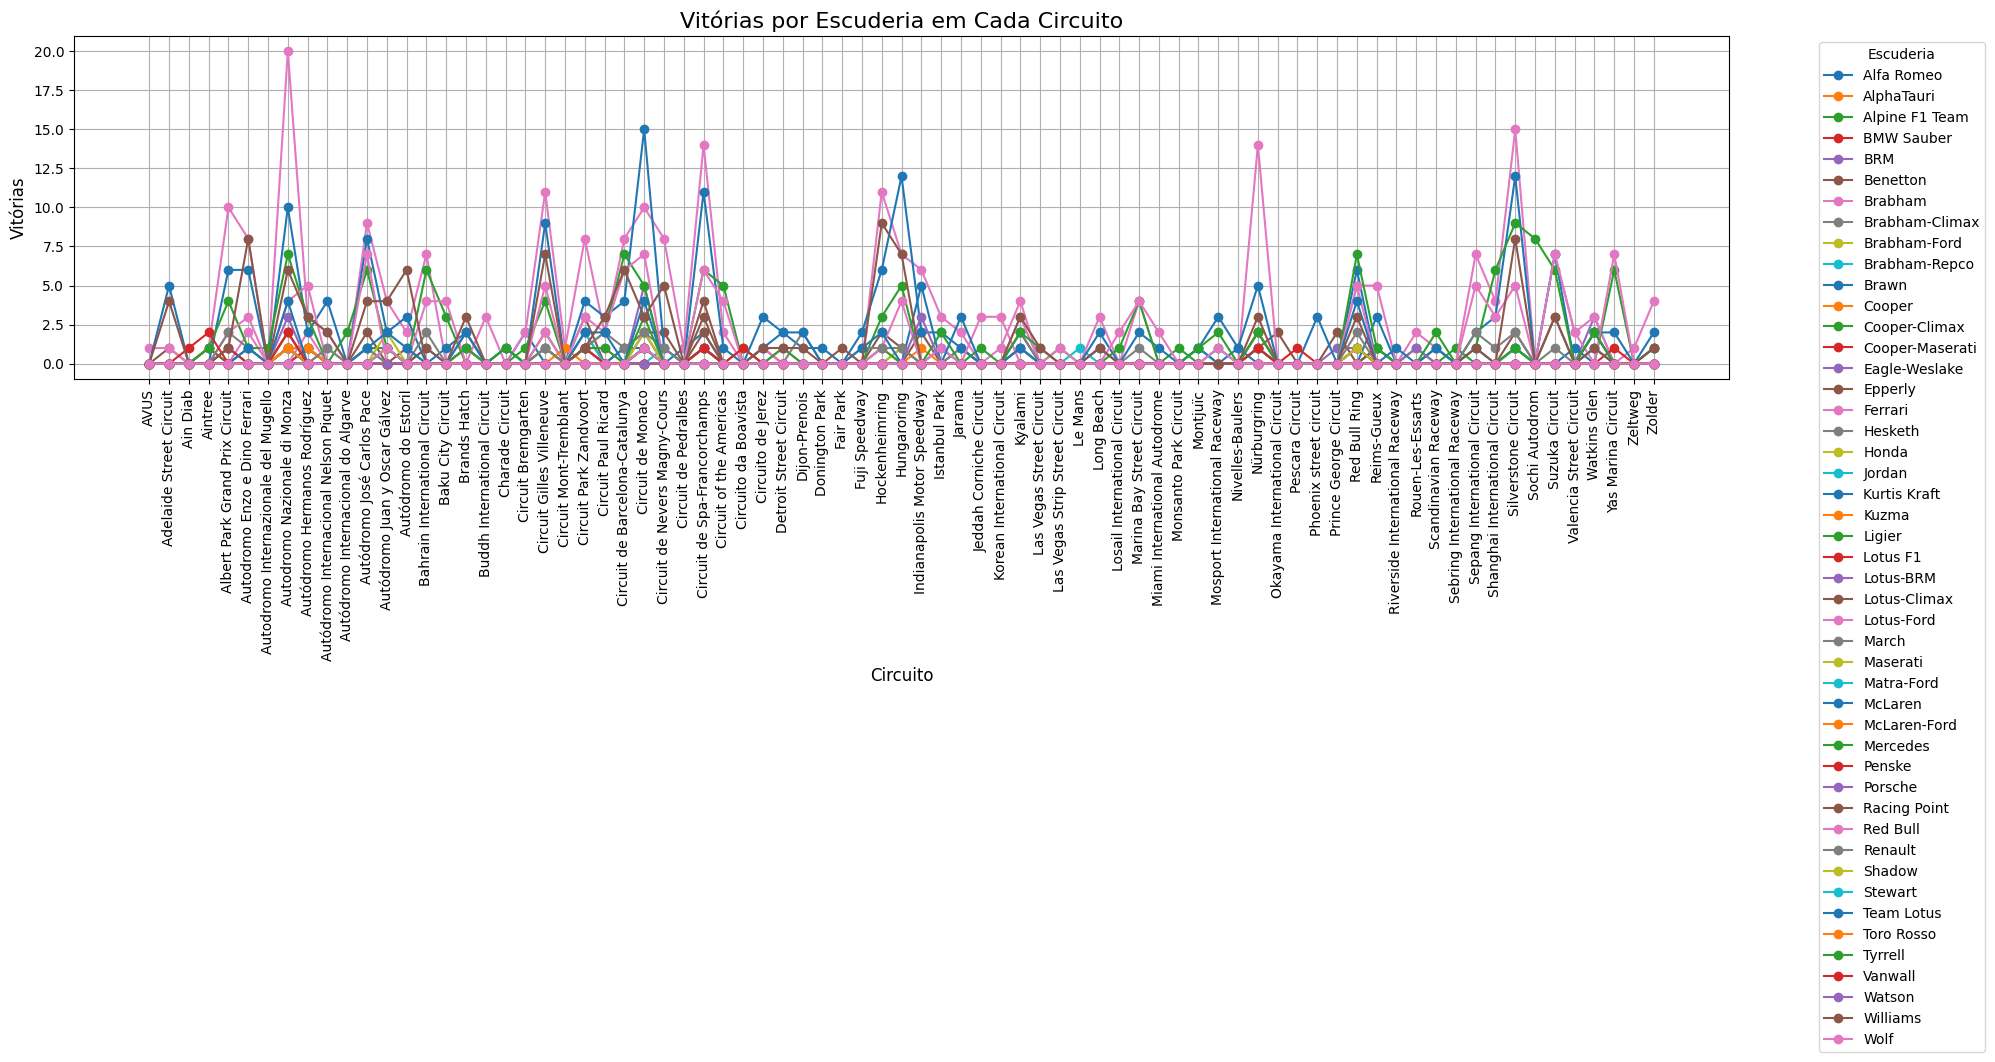

In [37]:
pivot_df = victories_by_team_circuit.pivot_table(
    index="constructorName",
    columns="circuitName",
    values="win_count",
    fill_value=0
)
plt.figure(figsize=(20, 8))

for team in pivot_df.index:
    plt.plot(pivot_df.columns, pivot_df.loc[team], marker='o', label=team)

plt.title("Vitórias por Escuderia em Cada Circuito", fontsize=16)
plt.xlabel("Circuito", fontsize=12)
plt.ylabel("Vitórias", fontsize=12)
plt.xticks(rotation=90)
plt.legend(title="Escuderia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

##### 2. Vitórias das Top 5 Escuderias nos 10 Circuitos com Mais Corridas

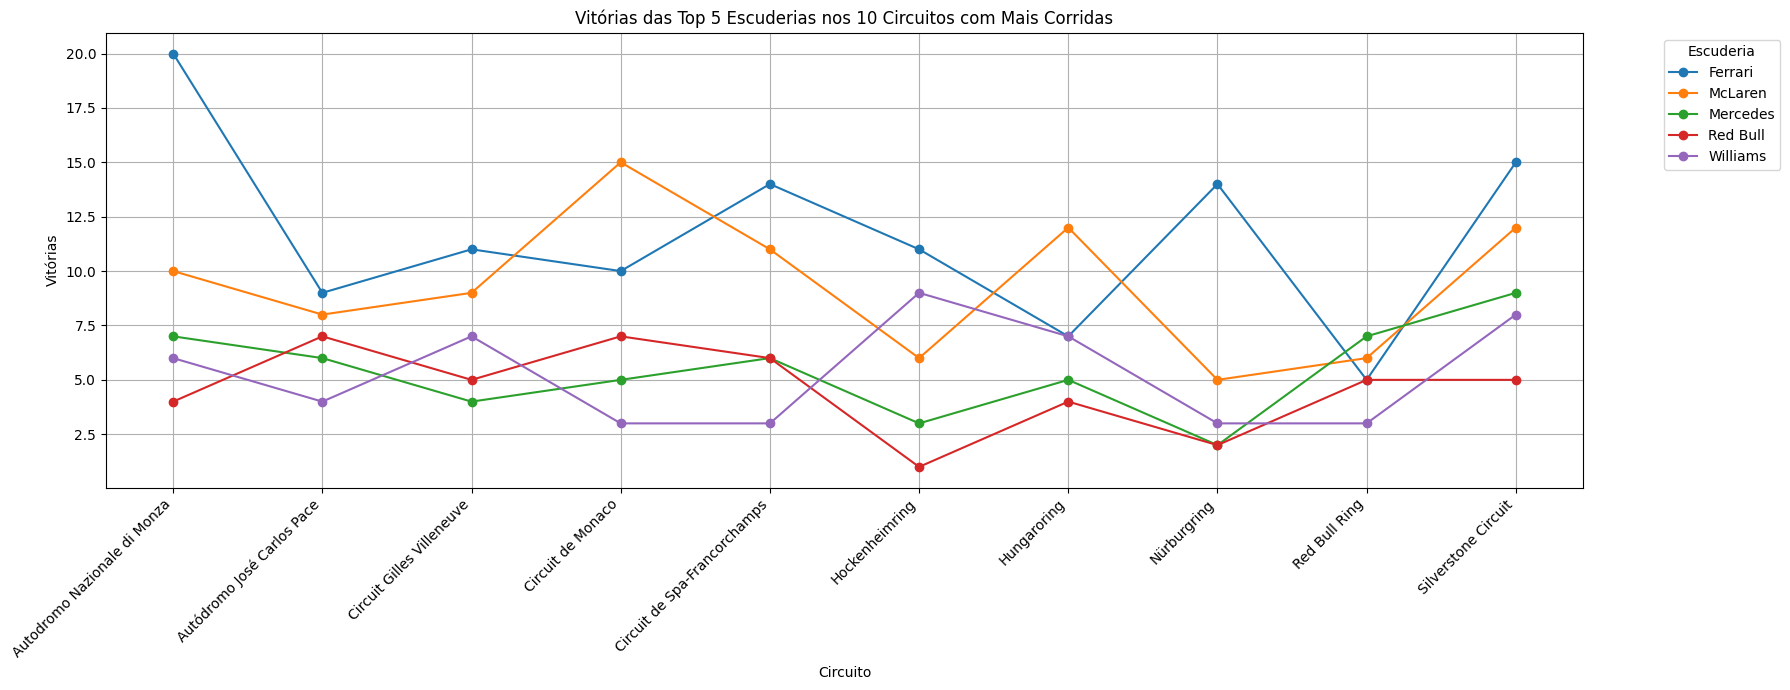

In [35]:
top_teams = (
    victories_by_team_circuit.groupby("constructorName")["win_count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered_teams = victories_by_team_circuit[victories_by_team_circuit["constructorName"].isin(top_teams)]

top_circuits = (
    races["circuitId"]
    .value_counts()
    .head(10)
    .index
)
top_circuit_names = circuits[circuits["circuitId"].isin(top_circuits)]["name"].tolist()
filtered_data = filtered_teams[filtered_teams["circuitName"].isin(top_circuit_names)]

pivot_df = filtered_data.pivot_table(
    index="constructorName",
    columns="circuitName",
    values="win_count",
    fill_value=0
)

plt.figure(figsize=(18, 7))

for team in pivot_df.index:
    plt.plot(pivot_df.columns, pivot_df.loc[team], marker='o', label=team)

plt.title("Vitórias das Top 5 Escuderias nos 10 Circuitos com Mais Corridas")
plt.xlabel("Circuito")
plt.ylabel("Vitórias")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title="Escuderia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 3. Média de vitórias das Top 5 escuderias com mais vitórias, contando apenas os top 10 circuitos mais recorrentes

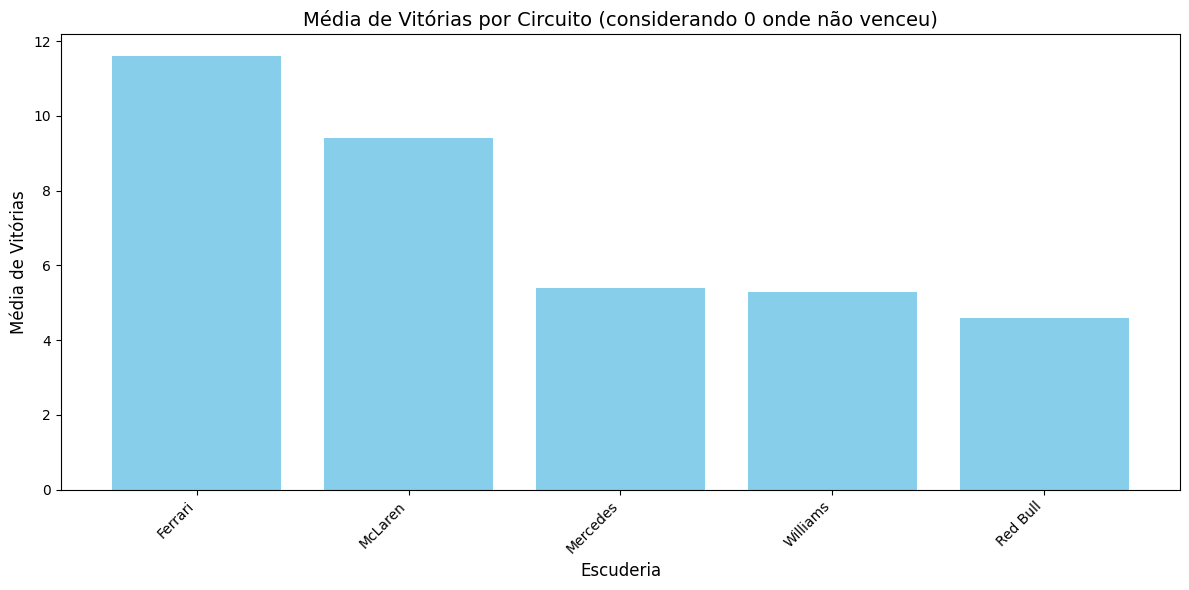

In [36]:
all_combinations = pd.MultiIndex.from_product(
    [top_teams, top_circuit_names],
    names=["constructorName", "circuitName"]
).to_frame(index=False)

full_data = all_combinations.merge(
    victories_by_team_circuit, how="left", on=["constructorName", "circuitName"]
).fillna({"win_count": 0})

mean_with_zeros = full_data.groupby("constructorName")["win_count"].mean().reset_index(name="mean_wins")

mean_with_zeros_sorted = mean_with_zeros.sort_values(by="mean_wins", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(mean_with_zeros_sorted["constructorName"], mean_with_zeros_sorted["mean_wins"], color='skyblue')

plt.title("Média de Vitórias por Circuito (considerando 0 onde não venceu)", fontsize=14)
plt.xlabel("Escuderia", fontsize=12)
plt.ylabel("Média de Vitórias", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

##### 4. Número de Escuderias Diferentes que Venceram por Circuito

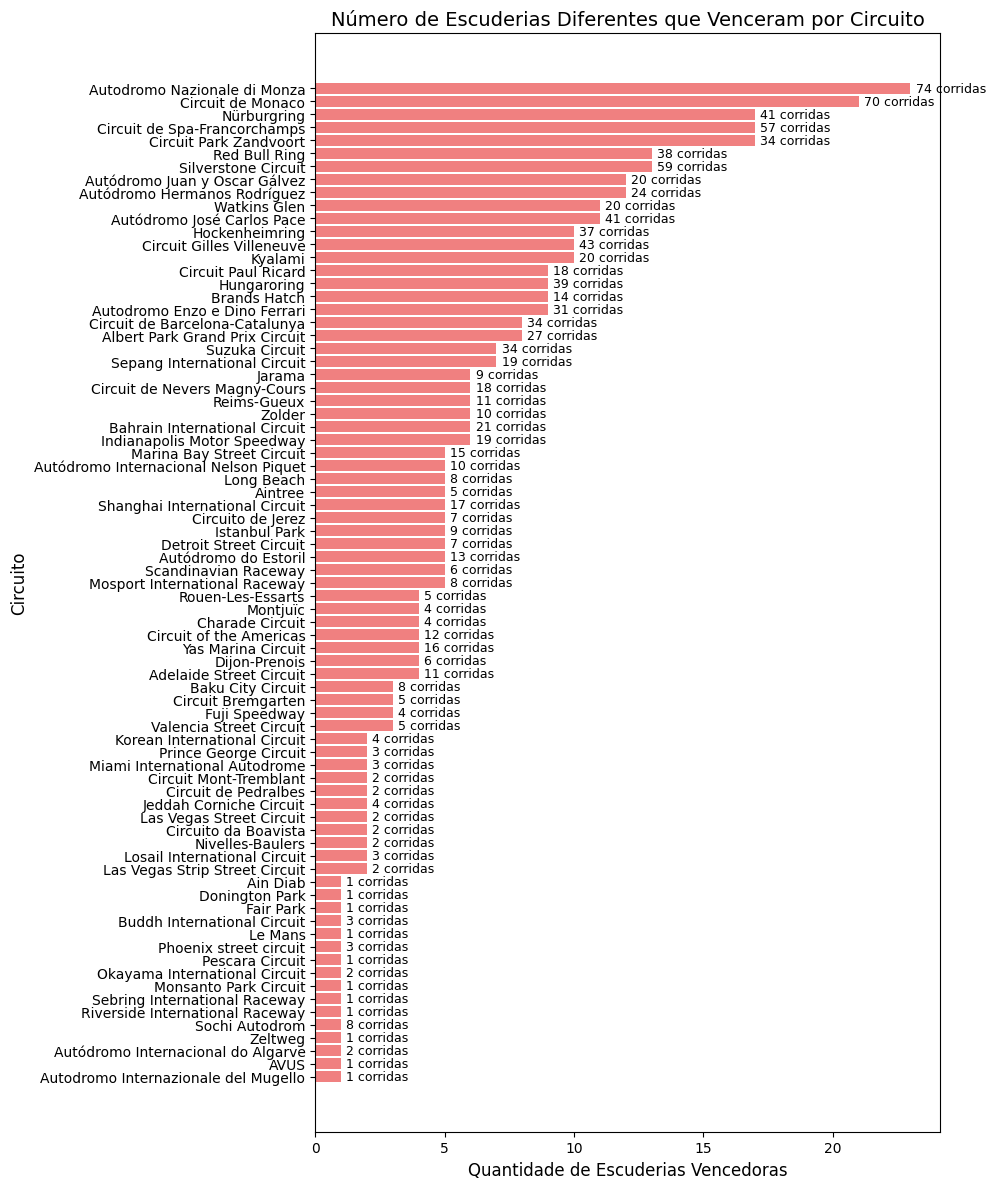

In [38]:
unique_winners_per_circuit = (
    victories_by_team_circuit.groupby("circuitName")["constructorName"]
    .nunique()
    .reset_index(name="unique_winning_teams")
    .sort_values(by="unique_winning_teams", ascending=False)
)

sorted_circuits = unique_winners_per_circuit.sort_values(by="unique_winning_teams", ascending=True)

races_per_circuit = races.groupby("circuitId").size().reset_index(name="race_count")
races_with_names = races_per_circuit.merge(circuits[["circuitId", "name"]], on="circuitId")

circuit_stats = sorted_circuits.merge(races_with_names, left_on="circuitName", right_on="name")

plt.figure(figsize=(10, 12))
bars = plt.barh(circuit_stats["circuitName"], circuit_stats["unique_winning_teams"], color="lightcoral")

plt.title("Número de Escuderias Diferentes que Venceram por Circuito", fontsize=14)
plt.xlabel("Quantidade de Escuderias Vencedoras", fontsize=12)
plt.ylabel("Circuito", fontsize=12)

for bar, races in zip(bars, circuit_stats["race_count"]):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{races} corridas", va='center', fontsize=9)

plt.tight_layout()
plt.show()

##### 5. Circuito Mais Favorável para Cada Escuderia

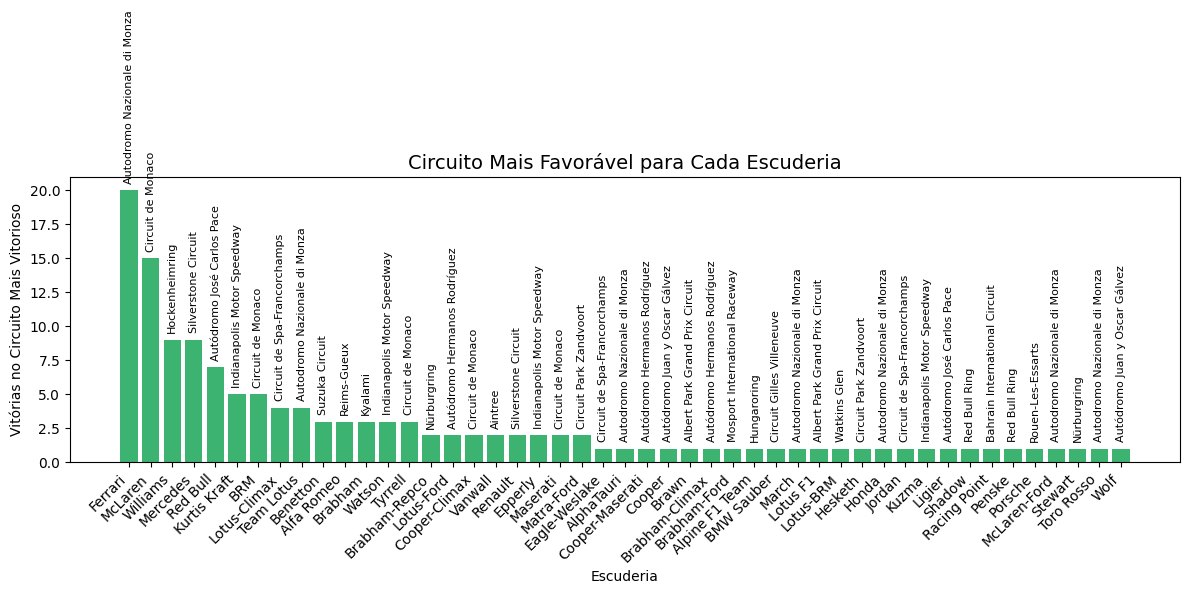

In [39]:
team_mode = victories_by_team_circuit.loc[victories_by_team_circuit.groupby("constructorName")["win_count"].idxmax()].reset_index(drop=True).rename(columns={"circuitName": "most_won_circuit", "win_count": "wins_in_that_circuit"})[["constructorName", "most_won_circuit", "wins_in_that_circuit"]]
team_mode_sorted = team_mode.sort_values(by="wins_in_that_circuit", ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(team_mode_sorted["constructorName"], team_mode_sorted["wins_in_that_circuit"], color="mediumseagreen")

for bar, circuit in zip(bars, team_mode_sorted["most_won_circuit"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             circuit, ha='center', va='bottom', fontsize=8, rotation=90)

plt.title("Circuito Mais Favorável para Cada Escuderia", fontsize=14)
plt.xlabel("Escuderia")
plt.ylabel("Vitórias no Circuito Mais Vitorioso")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()